# This notebook compares eukaryotic taxa seen in shotgun metagenomes with those in metabarcoding sequence data. It is designed to use three different annotation outputs: 1) sourmash (read-based annotation of shotgun metagenomes), 2) taxonomic annotation (mmseqs-lca) and quantification (TPM) of assembled contigs, and 3) DADA2, BLAST, and MEGAN LCA for metabarcoding data. Sourmash databases were GTDB and MMETSP, while mmseqs and BLAST databases were NCBI-nr.

### This is currently written to assess taxa at the class level, but can be modified for other levels of taxonomic resolution.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import pandas as pd
import os as os
import glob as glob
import numpy as np
import functools as ft
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## 01. Shotgun  metagenome sourmash results: Compile lists of observed taxa and calculate prokaryotic vs eukaryotic fractions

### Function to generate domain- and species-level data

In [3]:
def compile_taxa_lists(sourmash, dataset, stats):
    tax = pd.read_csv(sourmash)
    # Get total number of bps in metagenome data set
    bps_grouped = stats[['Dataset', '# bps (QCd)']].groupby(['Dataset']).sum()
    total_bps = bps_grouped.loc[dataset][0].astype(int)
    # Get fraction of metagenome for each domain (or "superkingdom")
    superk = tax[tax['rank'] == 'superkingdom']
    # Prokaryotes
    arch = superk[superk['lineage'].isin(['d__Archaea'])]['f_weighted_at_rank'].mean()
    bac = superk[superk['lineage'].isin(['d__Bacteria'])]['f_weighted_at_rank'].mean()
    prok_frac = arch + bac
    unass_frac = superk[superk['lineage'] == 'unclassified']['f_weighted_at_rank'].mean()
    if superk['lineage'].eq('Eukaryota').any():
        euk_frac = superk[superk['lineage'] == 'Eukaryota']['f_weighted_at_rank'].mean()
    else:
        euk_frac = 0
    # Calculate # bps per domain in metagenome
    prok_bps = prok_frac * total_bps
    prok_bps = prok_bps.round(0).astype(int)
    unass_bps = unass_frac * total_bps
    unass_bps = unass_bps.round(0).astype(int)
    euk_bps = euk_frac * total_bps
    euk_bps = euk_bps.round(0).astype(int)
    # Make dataframe with sample name and bps
    dataset_bps = pd.DataFrame({'Dataset' : pd.Series(dataset, dtype='str'), 
                               'total_bps': pd.Series(total_bps, dtype='int'),
                               'prok_bps': pd.Series(prok_bps, dtype='int'),
                               'euk_bps': pd.Series(euk_bps, dtype='int'),
                               'unass_bps': pd.Series(unass_bps, dtype='int')}) 
    tax['Dataset'] = dataset
    tax = tax[['Dataset', 'lineage', 'rank', 'f_weighted_at_rank']].groupby(['Dataset', 'lineage', 'rank']).sum().reset_index()
    tax = tax[tax['rank'] == 'species'] # this can be changed to any taxonomic level
    lineage = tax[['lineage', 'f_weighted_at_rank']].copy()
    # n should be changed to however many ranks are in the desired taxonomic level
    lineage[['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']] = lineage['lineage'].str.split(';', 
                                                                n=7, expand=True) 
    # Filter for eukaryotic classifications only
    euks = lineage.loc[lineage['Domain'] == 'Eukaryota']
    # Get taxa with unknown phyla
    unknown = euks[euks['Phylum'] == 'Unknown']
    # Change this to whatever taxonomic rank; currently set at 'Phylum'
    tax_level = euks[['Phylum','Class','Order', 'Family', 'Genus', 'Species', 'f_weighted_at_rank']].set_index('Phylum')
    # Multiply weighted fraction of taxon by total bps to get metagenome fraction of taxon
    tax_level['bp_fraction'] = tax_level['f_weighted_at_rank'] * euk_bps
    tax_level = tax_level.drop(columns=['f_weighted_at_rank'])
    tax_level['Metagenome Dataset'] = dataset
    return(tax_level, dataset_bps, unknown)

### Apply functions to all samples in all directories

In [5]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/sourmash/summaries/dataset")

In [6]:
stats = pd.read_csv("mgn_seq_stats.csv")
bps_grouped = stats[['Dataset', '# bps (QCd)']].groupby(['Dataset']).sum()
bps_grouped

,# bps (QCd)
Dataset,
CANON2018,5.814207e+12
RREAS2018,6.169170e+11
RREAS2019,3.098577e+11


In [7]:
# empty list for taxon-level observations
df_tax_mgns = []
# empty list for all eukaryotic reads and base pairs
df_sample_bps = []
# unknown
unknown_all = []

for file in glob.glob('*summarized.csv'):
    data, b = file.split('.', maxsplit=1)
    tax, bps, unknown = compile_taxa_lists(file, data, stats)
    df_tax_mgns.append(tax)
    df_sample_bps.append(bps)
    unknown_all.append(unknown)

df_tax_mgns = pd.concat(df_tax_mgns).reset_index()
df_mgns_bps = pd.concat(df_sample_bps)
df_mgns_bps['euk_bp_fraction'] = df_mgns_bps['euk_bps'] / df_mgns_bps['total_bps']
df_mgns_bps['prok_bp_fraction'] = df_mgns_bps['prok_bps'] / df_mgns_bps['total_bps']
df_mgns_bps['unass_bp_fraction'] = df_mgns_bps['unass_bps'] / df_mgns_bps['total_bps']
unknown_all = pd.concat(unknown_all)

#### Calculate average fraction of eukaryotic base pairs across all samples

In [8]:
df_mgns_bps.head()

,Dataset,total_bps,prok_bps,euk_bps,unass_bps,euk_bp_fraction,prok_bp_fraction,unass_bp_fraction
0,RREAS2018,616916961237,144911899794,11198978918,460806082525,0.018153,0.234897,0.746950
0,CANON2018,5814206629362,1533773518147,35948696461,4244484414753,0.006183,0.263798,0.730020
0,RREAS2019,309857691517,57016114617,10504129507,242868476378,0.033900,0.184007,0.783807


In [9]:
avg_euk_percent = np.average(df_mgns_bps['euk_bp_fraction'])
avg_prok_percent = np.average(df_mgns_bps['prok_bp_fraction'])
avg_unass_percent = np.average(df_mgns_bps['unass_bp_fraction'])
avg_euk_bps = np.average(df_mgns_bps['euk_bps'])
avg_prok_bps = np.average(df_mgns_bps['prok_bps'])
avg_unass_bps = np.average(df_mgns_bps['unass_bps'])
avg_prok_bps

np.float64(578567177519.3334)

#### Calculate average fraction of total reads per sample from fraction of base pairs

In [10]:
mgn_stats = pd.read_csv("mgn_seq_stats.csv")
avg_bps = np.average(mgn_stats['# bps (QCd)'])
avg_bps

np.float64(30921932486.77339)

#### Create a data frame with the average number of reads, average fraction of eukaryotic base pairs, and average fraction of eukaryotic reads for metagenomes

In [11]:
euk_frac_mgns = pd.DataFrame({'Sequence type': 'Metagenome reads', 
                              'Avg num bps or contigs': [avg_bps],
                           'Avg % euk bps or contigs' : [avg_euk_percent], 
                              'Avg % prok bps or contigs' : [avg_prok_percent],
                             'Avg % unass bps or contigs' : [avg_unass_percent],
                              'Avg num euk bps or contigs' : [avg_euk_bps],
                              'Avg num prok bps or contigs' : [avg_prok_bps],
                              'Avg num unass bps or contigs' : [avg_unass_bps]})

In [12]:
euk_frac_mgns

,Sequence type,Avg num bps or contigs,Avg % euk bps or contigs,Avg % prok bps or contigs,Avg % unass bps or contigs,Avg num euk bps or contigs,Avg num prok bps or contigs,Avg num unass bps or contigs
0,Metagenome reads,3.092193e+10,0.019412,0.227567,0.753592,1.921727e+10,5.785672e+11,1.649386e+12


In [13]:
euk_frac_mgns.to_csv("Metagenome_eukaryotic_reads_bps.csv", index=None)

## 02. Shotgun  metagenome contig annotation and associated TPMs: Compile fractions of observed taxa and calculate prokaryotic vs eukaryotic fractions

In [14]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/mmseqs/coverm-lca-filt-ALL")

## Combine metagenome coverage by contig with taxonomic annotation by contig

### Function to merge contig annotations with coverages

In [15]:
def merge_taxonomy_coverage(tpms, lca):
    # Contig coverage
    coverage = pd.read_csv(tpms, sep='\t', header=0, names=['Contig', 'TPM'])
    # Add column for sample name and remove contigs with TPM of 0
    name, b = tpms.split('_c', maxsplit=1)
    coverage['Sample'] = name
    coverage = coverage[coverage['TPM'] != 0.0]
    # Calculate total TPM value
    tpm_total = coverage['TPM'].sum()

    # LCA output
    tax = pd.read_csv(lca, sep='\t')
    # If Phylum is unknown ("nan"), replace with Class name; if Class is unknown, replace with Order
    tax.loc[:, 'c'] = np.where(tax['c'].isna(), tax['o'], tax['c'])
    tax.loc[:, 'p'] = np.where(tax['p'].isna(), tax['c'], tax['p'])

    # Merge on contigs
    df = pd.merge(coverage, tax, on='Contig', how='outer')

    # set Domain to Unclassified if contig with coverage had no annotation
    df['d'] = df['d'].fillna(value='Unclassified')

    # Calculate percent TPM
    if tpm_total == 0:
        df['percent_TPM'] = 0
    else:
        df['percent_TPM'] = df['TPM'] / tpm_total
    
    # Make eukaryotic and prokaryotic ASV tables
    df_euks = df[df['d'] == 'Eukaryota'].drop(columns=['d'])
    df_proks = df[(df['d'] == 'Bacteria') | (df['d'] == 'Archaea')].drop(columns=['d'])
    df_unass = df[(df['d'] == 'Unclassified')]
    # Change this to whatever taxonomic rank; currently set at Class
    tax_level = df_euks[['Sample', 'percent_TPM', 'Best_tax']].groupby(['Sample', 'Best_tax']).sum().reset_index()
    
    return(tax_level, df_euks, df_proks, df_unass)

### Function to identify matching LCA taxonomy and coverage files

In [16]:
def find_matching_file_by_prefix(filename, search_dir, old_suffix='-mmseqs_uniref_lca_filt.tsv', new_suffix='_covermcontig-out'):
    base = os.path.basename(filename)
    
    if base.endswith(old_suffix):
        # Strip the old suffix to get the prefix
        prefix = base[:-len(old_suffix)]
        # Construct the new filename
        match_name = prefix + new_suffix
        match_path = os.path.join(search_dir, match_name)
        if os.path.exists(match_path):
            return match_name
        else:
            return None
    else:
        return None

### Function to calculate total metagenome coverage

In [17]:
def get_tpm_sum(tpms):
    # Contig coverage
    coverage = pd.read_csv(tpms, sep='\t', header=0, names=['Contig', 'TPM'])
    # Add column for sample name and remove contigs with TPM of 0
    name, b = tpms.split('_c', maxsplit=1)
    coverage['Sample'] = name
    coverage = coverage[coverage['TPM'] != 0.0]
    # Calculate total TPM value
    tpm_total = coverage['TPM'].sum()
    print(name, tpm_total)

#### Check coverages of all metagenomes

In [18]:
for file in glob.glob('*out'):
    get_tpm_sum(file)

zr2760_61 6103855.015412822
D0063A 17706835.368853584
zr2760_25 4939726.436220389
D0105A 10065080.878202029
1903c123_70m-1 6173950.956467183
1903c117_5m-1 4030702.1118850308
1903c122_100m-2 5250098.025240639
D0057A 10514229.25853963
zr2760_40 5765089.680916791
D0163A 11538789.951952977
1903c114_100m-3 5297926.726396531
1903c144_13m-1 567843.59870252
1903c111_10m-2 5207264.6474058
zr2760_31 7397363.725974124
zr2760_54 2370284.3959497386
D0152A 12189767.659548858
1903c118_23m-1 1603323.7177271
1903c111_100m-1 2763517.764389187
zr2760_75 4217886.923287636
D0100A 11237428.73280382
zr2760_10 7801070.485314476
D0128A 14566934.66445354
D0052A 13014980.278500995
1903c124_15m-2 5814888.270948071
1903c118_5m-2 2358767.7146671
1903c117_50m-2 7978787.594504051
zr2760_71 5642310.9116675
1903c126_100m-2 5714040.36167216
1903c118_100m-2 3515966.765171642
1903c122_28m-1 4566727.263129386
1903c122_5m-2 4843249.51377952
1903c123_10m-2 6053710.843701925
zr2760_35 9185580.504933052
1903c127_7m-1 3954844.8

### Compile results from samples grouped by dataset

In [19]:
mmseqs_tax = []
mmseqs_euk = []
mmseqs_prok = []
mmseqs_unass = []

for file in glob.glob('*filt.tsv'):
    name, b = file.split('-', maxsplit=1)
    tpms = find_matching_file_by_prefix(file, './')
    #print(tpms, file)
    taxa, euks, proks, unass = merge_taxonomy_coverage(tpms, file)
    mmseqs_tax.append(taxa)
    mmseqs_euk.append(euks)
    mmseqs_prok.append(proks)
    mmseqs_unass.append(unass)

mmseqs_tax = pd.concat(mmseqs_tax).rename(columns={'Sample': 'Metagenome sample'})
mmseqs_euk = pd.concat(mmseqs_euk).rename(columns={'Sample': 'Metagenome sample'})
mmseqs_prok = pd.concat(mmseqs_prok).rename(columns={'Sample': 'Metagenome sample'})
mmseqs_unass = pd.concat(mmseqs_unass).rename(columns={'Sample': 'Metagenome sample'})

In [20]:
mmseqs_unass.head()

,Contig,TPM,Metagenome sample,Tax_level,Best_tax,d,p,k,c,o,f,g,s,percent_TPM
88,D0174A_S47_0089,48.755062,D0174A,no rank,root,Unclassified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980065e-06
170,D0174A_S47_0171,55.683870,D0174A,NaN,NaN,Unclassified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.403576e-06
186,D0174A_S47_0187,31.666498,D0174A,no rank,root,Unclassified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.935558e-06
191,D0174A_S47_0192,14.990702,D0174A,no rank,root,Unclassified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.162796e-07
196,D0174A_S47_0197,48.398453,D0174A,no rank,root,Unclassified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.958268e-06


### Get total contig count per sample

In [21]:
mmseqs_all = pd.concat([mmseqs_euk, mmseqs_prok, mmseqs_unass])
mmseqs_contigs = mmseqs_all[['Metagenome sample', 'Contig']]
mmseqs_contig_count = mmseqs_contigs.groupby('Metagenome sample').count()
mmseqs_contig_count.head()

,Contig
Metagenome sample,
1903_buk5-1,722829
1903_buk5-2,721343
1903_buk6-1,570377
1903_buk6-2,352602
1903buk1_0m-1,3246


### Rename taxonomic lineage columns to match the amplicon data (see next section)

#### Add lineage back to tax

In [22]:
tax_euks = mmseqs_euk.drop(columns=['Contig', 'TPM', 'Metagenome sample', 'Tax_level', 
                                    'percent_TPM']).drop_duplicates().reset_index(drop=True)
tax_proks = mmseqs_prok.drop(columns=['Contig', 'TPM', 'Metagenome sample', 'Tax_level', 
                                      'percent_TPM']).drop_duplicates().reset_index(drop=True)
tax_all = pd.concat([tax_euks, tax_proks])
mmseqs_tax = mmseqs_tax.merge(tax_all, on='Best_tax', how='inner')

In [23]:
dfs = [mmseqs_tax, mmseqs_euk, mmseqs_prok]

In [24]:
for df in dfs:
    df.rename(columns={'k': 'Kingdom', 'p': 'Phylum', 'c': 'Class', 'o': 'Order', 
                            'f': 'Family', 'g': 'Genus', 's': 'Species'}, inplace=True)

In [25]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/mmseqs")

In [26]:
mmseqs_euk.to_csv("CCE_2018-2019_mmseqs_euk_lineage_tpms.csv", index=None)
mmseqs_prok.to_csv("CCE_2018-2019_mmseqs_prok_lineage_tpms.csv", index=None)
mmseqs_unass.to_csv("CCE_2018-2019_mmseqs_unass_lineage_tpms.csv", index=None)
mmseqs_tax.to_csv("CCE_2018-2019_mmseqs_taxa.csv", index=None)

In [27]:
mmseqs_contig_count.to_csv("CCE_2018-2019_mmseqs_total_contigs.csv", index=None)

In [123]:
mmseqs_euk = pd.read_csv("CCE_2018-2019_mmseqs_euk_lineage_tpms.csv")

In [150]:
mmseqs_euk.head("CCE_2018-2019_mmseqs_euk_lineage_tpms.csv")

,Contig,TPM,Metagenome sample,Tax_level,Best_tax,Phylum,Kingdom,Class,Order,Family,Genus,Species,percent_TPM
119,D0174A_S47_0120,32.114580,D0174A,phylum,Bacillariophyta,Bacillariophyta,NaN,NaN,NaN,NaN,NaN,NaN,0.000002
134,D0174A_S47_0135,48.623592,D0174A,superkingdom,Eukaryota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000003
183,D0174A_S47_0184,32.295506,D0174A,order,Thalassiosirales,Bacillariophyta,NaN,Coscinodiscophyceae,Thalassiosirales,NaN,NaN,NaN,0.000002
248,D0174A_S47_0249,27.887200,D0174A,superkingdom,Eukaryota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000002
265,D0174A_S47_0266,16.516504,D0174A,phylum,Bacillariophyta,Bacillariophyta,NaN,NaN,NaN,NaN,NaN,NaN,0.000001


### Calculate % contigs classified as prokaryote vs eukaryote vs unassigned

In [28]:
contig_euk_frac = mmseqs_euk[['Metagenome sample', 'percent_TPM']].rename(columns={'percent_TPM': 'euk_contig_percent'})
contig_euk_frac = contig_euk_frac.groupby('Metagenome sample').sum()
contig_prok_frac = mmseqs_prok[['Metagenome sample', 'percent_TPM']].rename(columns={'percent_TPM': 'prok_contig_percent'})
contig_prok_frac = contig_prok_frac.groupby('Metagenome sample').sum()
contig_unass_frac = mmseqs_unass[['Metagenome sample', 'percent_TPM']].rename(columns={'percent_TPM': 'unass_contig_percent'})
contig_unass_frac = contig_unass_frac.groupby('Metagenome sample').sum()
contig_prok_euk_frac_df = contig_euk_frac.merge(contig_prok_frac, left_index=True, right_index=True)
contig_frac_df = contig_prok_euk_frac_df.merge(contig_unass_frac, left_index=True, right_index=True)
contig_frac_df = contig_frac_df.merge(mmseqs_contig_count, left_index=True, right_index=True).rename(columns={'Contig': 'Total_contigs'})
contig_frac_df.head(5)

,euk_contig_percent,prok_contig_percent,unass_contig_percent,Total_contigs
Metagenome sample,,,,
1903_buk5-1,0.185821,0.304237,0.509942,722829
1903_buk5-2,0.177641,0.316295,0.506064,721343
1903_buk6-1,0.057686,0.554939,0.387375,570377
1903_buk6-2,0.050693,0.579238,0.370069,352602
1903buk1_0m-1,0.129014,0.494236,0.376750,3246


In [29]:
contig_frac_df.to_csv("mmseqs_contig_counts_by_domain_withunass.csv")

## 03. Metabarcoding data: Compile lists of observed taxa

### Function to calculate total number of reads and bps per sample, filter out bacterial and unclassified ASVs, and convert read counts to relative abundance values ('frequencies')

In [10]:
def counts_to_freq(file, marker_gene, read_len):
    asvs = pd.read_csv(file, header=0)
    # Move the taxonomy columns to the first positions in the df
    cols_to_move = ['Domain', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
    asvs = asvs[ cols_to_move + [ col for col in asvs.columns if col not in cols_to_move ] ]
    # Convert non-sample columns to strings so sum function works
    asvs = asvs.astype({col: str for col in asvs.columns[0:9]})
    # Get total number of reads and bps per sample
    asvs.loc['total']= asvs.sum()
    sample_reads = asvs.iloc[-1:,9:].reset_index()
    sample_reads = pd.melt(sample_reads, id_vars='index')
    sample_reads = sample_reads.iloc[:,-2:].rename(columns=
                                       {'variable':'%s sample' % marker_gene, 
                                        'value':'total %s reads' % marker_gene})
    sample_reads['total %s bps' % marker_gene] = sample_reads['total %s reads' % marker_gene] * read_len # 180 bps for 18S, 313 bps for COI
    # Remove ASVs with no read counts in any samples
    asvs.loc[:, 'sum'] = asvs.iloc[:,9:].sum(axis=1)
    asvs_filt = asvs[asvs['sum'] != 0]
    # Replace 'nan' annotations with 'Domain'
    asvs_filt = asvs_filt.replace('nan', 'unassigned')
    # Replace unknown Phyla with Class name and unknown Classes with Order name
    asvs_filt.loc[:, 'Phylum'] = np.where(asvs_filt['Phylum'] == 'unknown', asvs_filt['Class'], asvs_filt['Phylum'])
    asvs_filt.loc[:, 'Class'] = np.where(asvs_filt['Class'] == 'unknown', asvs_filt['Order'], asvs_filt['Class'])
    # Calculate frequencies
    asvs_freq = asvs_filt.copy()
    asvs_freq.iloc[:,9:] = asvs_freq.iloc[:,9:] / asvs_freq.iloc[-1,9:]
    # Remove the column and row with ASV read count sums
    asvs_filt = asvs_filt.iloc[:-1,:-1]
    asvs_freq = asvs_freq.iloc[:-1,:-1]
    return(asvs_filt, asvs_freq, sample_reads)

### Test on one file

In [49]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/COI comparison/ASV tables")

In [19]:
file = 'RREAS2019_COI_asv_filtered_noCs_mgnmatches_tax.csv'
gene = 'COI'
len = 313

In [20]:
taxa_filt, taxa_freq, reads = counts_to_freq(file, gene, len)

/var/folders/df/9pc0s5c92v9637mf3mll4y5c0000gn/T/ipykernel_61441/1485596940.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  asvs.loc[:, 'sum'] = asvs.iloc[:,9:].sum(axis=1)


In [30]:
counts = reformat_ASV_table(taxa_filt, 'COI')

In [48]:
sub = counts[counts['COI sample'].str.contains("Nisk_SM_Night")]
sub['COI sample'].unique()

array(['CN19_Nisk_SM_Night_5m_1', 'CN19_Nisk_SM_Night_5m_2',
       'CN19_Nisk_SM_Night_23m_1', 'CN19_Nisk_SM_Night_100m_1',
       'CN19_Nisk_SM_Night_100m_2'], dtype=object)

### Function to reformat taxa lists

#### Excluding taxa with unknown class/genus filters out A LOT of ASVs. Currently I have opted to keep in unknown taxa.

In [11]:
def reformat_ASV_table(df, marker_gene):
    samples = [col for col in df.columns if '1' in col] # Only sample column names have numbers
    cols_to_drop = ['Kingdom','Species', 'ASV ID']
    df = df.drop(cols_to_drop, axis=1)
    taxon = [x for x in df.columns if '1' not in x]
    df_melt = pd.melt(df, id_vars=taxon, value_vars=samples)
    df_asvs = df_melt.rename(columns = {'variable':'%s sample' % marker_gene, 
                                        'value':'%s reads' % marker_gene})
    df_asvs = df_asvs[ (df_asvs['%s reads' % marker_gene] != 0.0) & (df_asvs['%s reads' % marker_gene].notna()) ]
    return(df_asvs)

### Generate dataframes for (1) phylum- and class-level taxon frequences per sample and (2) reads and bps per sample

#### COI

In [50]:
df_tax_COI = []
df_freq_COI = []
df_reads_COI = []

for file in glob.glob('*mgnmatches_tax.csv'):
    taxa_filt, taxa_freq, reads = counts_to_freq(file, 'COI', 321)
    counts = reformat_ASV_table(taxa_filt, 'COI')
    freq = reformat_ASV_table(taxa_freq, 'COI')
    df_tax_COI.append(counts)
    df_freq_COI.append(freq)
    df_reads_COI.append(reads)

df_tax_COI = pd.concat(df_tax_COI, axis=0)
df_freq_COI = pd.concat(df_freq_COI, axis=0)
df_reads_COI = pd.concat(df_reads_COI)

/var/folders/df/9pc0s5c92v9637mf3mll4y5c0000gn/T/ipykernel_61441/1485596940.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  asvs.loc[:, 'sum'] = asvs.iloc[:,9:].sum(axis=1)


In [13]:
df_tax_COI.head(3)
#df_freq_COI.head(3)
#df_reads_COI.head(3)

,Domain,Phylum,Class,Order,Family,Genus,COI sample,COI reads
0,Eukaryota,Haptophyta,Isochrysidales,Isochrysidales,Noelaerhabdaceae,unassigned,Lasker18Sc122_3_D0052,3647.0
1,Eukaryota,Arthropoda,unassigned,unassigned,unassigned,g_,Lasker18Sc122_3_D0052,2347.0
2,Eukaryota,Haptophyta,Phaeocystales,Phaeocystales,Phaeocystaceae,Phaeocystis,Lasker18Sc122_3_D0052,4985.0


In [56]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/COI comparison/")
df_freq_COI.to_csv("COI_frequencies_all_tax_ranks_withBacUnass.csv", index=None)
df_tax_COI.to_csv("COI_readcounts_all_tax_ranks_withBacUnass.csv", index=None)
#df_reads_COI.to_csv("COI_reads_bps_total.csv", index=None)

#### Make table grouped by phylum and class

In [47]:
df_freq_COI_phy_class = df_freq_COI[['Phylum', 'Class', 'COI sample', 'COI reads']].groupby(['Phylum', 'Class', 'COI sample']).sum().reset_index()
df_freq_COI_phy_class.head(3)

,Phylum,Class,COI sample,COI reads
0,Annelida,Clitellata,CN19_Buck3_SN_0m_1,0.000023
1,Annelida,Polychaeta,CN18FESPkoa_SC24,0.000148
2,Annelida,Polychaeta,CN18FESPkoa_SC26,0.000108


In [49]:
df_freq_COI_phy_class.to_csv("COI_frequencies_Phylum_Class.csv", index=None)

#### 18S

In [50]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/18S comparison/ASV tables")

In [52]:
df_tax_18S = []
df_freq_18S = []
df_reads_18S = []

for file in glob.glob('*mgnmatches_tax.csv'):
    taxa_filt, taxa_freq, reads = counts_to_freq(file, '18S', 127)
    counts = reformat_ASV_table(taxa_filt, '18S')
    freq = reformat_ASV_table(taxa_freq, '18S')
    df_tax_18S.append(counts)
    df_freq_18S.append(freq)
    df_reads_18S.append(reads)

df_tax_18S = pd.concat(df_tax_18S, axis=0)
df_freq_18S = pd.concat(df_freq_18S, axis=0) #.drop(columns="Unnamed: 0")
df_reads_18S = pd.concat(df_reads_18S)

/var/folders/df/9pc0s5c92v9637mf3mll4y5c0000gn/T/ipykernel_54374/1485596940.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  asvs.loc[:, 'sum'] = asvs.iloc[:,9:].sum(axis=1)


In [53]:
df_tax_18S.head(3)
#df_freq_18S.head(3)
#df_reads_18S.head(3)

,Domain,Phylum,Class,Order,Family,Genus,18S sample,18S reads
0,unassigned,unassigned,unassigned,unassigned,unassigned,unassigned,CN18FESPkoa_SC24,15880
1,Eukaryota,Bacillariophyta,Bacillariophyceae,Bacillariales,Bacillariaceae,Pseudo-nitzschia,CN18FESPkoa_SC24,9712
2,Eukaryota,Polycystinea,Polycystinea,unassigned,unassigned,unassigned,CN18FESPkoa_SC24,11259


In [54]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/18S comparison")
df_tax_18S.to_csv("18S_readcounts_all_tax_ranks_withBacUnass.csv", index=None)
#df_reads_18S.to_csv("18S_reads_bps_total.csv", index=None)

In [55]:
df_freq_18S_phy_class = df_freq_18S[['Phylum', 'Class', '18S sample', '18S reads']].groupby(['Phylum', 'Class', '18S sample']).sum().reset_index()
df_freq_18S_phy_class.head(3)

,Phylum,Class,18S sample,18S reads
0,Acantharea,Acantharea,CN18FESPkoa_SC24,0.026317
1,Acantharea,Acantharea,CN18FESPkoa_SC26,0.0233
2,Acantharea,Acantharea,CN18FESPkoa_SC29,0.035743


In [56]:
df_freq_18S_phy_class.to_csv("18S_frequencies_Phylum_Class.csv")

## 04. Compare total numbers/fractions of eukaryotic reads in metagenomes and amplicons

#### Calculate average # total reads and average # eukaryotic reads and bps for amplicon samples

In [6]:
def calculate_eukaryotic_read_fraction(df_tax, df_reads, marker_gene):
    domains = df_tax[['Domain', '%s sample' % marker_gene, '%s reads' % marker_gene]]
    domains = domains.groupby(['Domain', '%s sample' % marker_gene]).sum()
    euks = domains.xs('Eukaryota', level=0).reset_index()
    unass = domains.xs('unassigned', level=0).reset_index()
    euk_fracs = pd.merge(df_reads, euks, on='%s sample' % marker_gene).rename(columns={'%s reads' % marker_gene : '%s euk reads' % marker_gene})
    unass_fracs = pd.merge(df_reads, unass, on='%s sample' % marker_gene).rename(columns={'%s reads' % marker_gene : '%s unclass reads' % marker_gene})
    euk_fracs['%s euk reads percent' % marker_gene] = euk_fracs['%s euk reads' % marker_gene] / euk_fracs['total %s reads' % marker_gene]
    unass_fracs['%s unclass reads percent' % marker_gene] = unass_fracs['%s unclass reads' % marker_gene] / unass_fracs['total %s reads' % marker_gene]
    domain_fracs = euk_fracs.merge(unass_fracs, how='outer', on=['%s sample' % marker_gene, 'total %s bps' % marker_gene])
    if marker_gene == '18S' : 
        domain_fracs['%s prok reads percent' % marker_gene] = 1 - domain_fracs['%s euk reads percent' % marker_gene] - domain_fracs['%s unclass reads percent' % marker_gene]
    elif marker_gene == 'COI' : 
        domain_fracs['%s prok reads percent' % marker_gene] = 0
    domain_fracs['%s euk bps' % marker_gene] = domain_fracs['%s euk reads percent' % marker_gene] * domain_fracs['total %s bps' % marker_gene]
    domain_fracs['%s prok bps' % marker_gene] = domain_fracs['%s prok reads percent' % marker_gene] * domain_fracs['total %s bps' % marker_gene]
    domain_fracs['%s unclass bps' % marker_gene] = domain_fracs['%s unclass reads percent' % marker_gene] * domain_fracs['total %s bps' % marker_gene]
    domain_fracs = domain_fracs.drop('total %s reads_y' % marker_gene, axis=1)
    domain_fracs = domain_fracs.rename(columns={'total %s reads_x' % marker_gene : 'total %s reads' % marker_gene})
    return(domain_fracs)

#### Read in existing COI and 18S files

In [57]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/COI comparison/")
df_reads_COI = pd.read_csv("COI_reads_bps_total.csv")
df_tax_COI = pd.read_csv("COI_readcounts_all_tax_ranks_withBacUnass.csv")

In [58]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/18S comparison")
df_reads_18S = pd.read_csv("18S_reads_bps_total.csv")
df_tax_18S = pd.read_csv("18S_readcounts_all_tax_ranks_withBacUnass.csv")

In [59]:
df_reads_COI.head()

,COI sample,total COI reads,total COI bps
0,Lasker18Sc122_3_D0052,34063,10934223
1,Lasker18Sc122_5_D0053,64735,20779935
2,Lasker18Sc122_17_D0057,76319,24498399
3,Lasker18Sc122_19_D0058,69006,22150926
4,Lasker18Sc123_3_D0063,35687,11455527


In [60]:
domain_fracs_18S = calculate_eukaryotic_read_fraction(df_tax_18S, df_reads_18S, '18S')
domain_fracs_18S.head(3)

,18S sample,total 18S reads,total 18S bps,18S euk reads,18S euk reads percent,18S unclass reads,18S unclass reads percent,18S prok reads percent,18S euk bps,18S prok bps,18S unclass bps
0,CN18FESPkoa_SC24,99632,17933760,69396,0.696523,30236,0.303477,0.000000e+00,12491280.0,0.000000e+00,5442480.0
1,CN18FESPkoa_SC26,45794,8242920,29464,0.643403,16330,0.356597,-5.551115e-17,5303520.0,-4.575740e-10,2939400.0
2,CN18FESPkoa_SC29,90730,16331400,63989,0.705268,26741,0.294732,-5.551115e-17,11518020.0,-9.065748e-10,4813380.0


In [61]:
domain_fracs_COI = calculate_eukaryotic_read_fraction(df_tax_COI, df_reads_COI, 'COI')
domain_fracs_COI.head(3)

,COI sample,total COI reads,total COI bps,COI euk reads,COI euk reads percent,COI unclass reads,COI unclass reads percent,COI prok reads percent,COI euk bps,COI prok bps,COI unclass bps
0,CN18FESPkoa_SC24,81287,26093127,13975.0,0.171922,67312.0,0.828078,0,4485975.0,0,21607152.0
1,CN18FESPkoa_SC26,101830,32687430,19679.0,0.193253,82151.0,0.806747,0,6316959.0,0,26370471.0
2,CN18FESPkoa_SC29,88847,28519887,12536.0,0.141096,76311.0,0.858904,0,4024056.0,0,24495831.0


#### Import contig numbers and calculate averages across data sets

In [62]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/mmseqs")
contig_frac_df = pd.read_csv("mmseqs_contig_counts_by_domain_withunass.csv")

In [63]:
contig_frac_df.head()

,Metagenome sample,euk_contig_percent,prok_contig_percent,unass_contig_percent,Total_contigs
0,1903_buk5-1,0.185821,0.304237,0.509942,722829
1,1903_buk5-2,0.177641,0.316295,0.506064,721343
2,1903_buk6-1,0.057686,0.554939,0.387375,570377
3,1903_buk6-2,0.050693,0.579238,0.370069,352602
4,1903buk1_0m-1,0.129014,0.494236,0.376750,3246


In [64]:
avg_total_contigs = contig_frac_df['Total_contigs'].mean()
avg_euk_contigs = contig_frac_df['euk_contig_percent'].mean()
avg_prok_contigs = contig_frac_df['prok_contig_percent'].mean()
avg_unass_contigs = contig_frac_df['unass_contig_percent'].mean()

In [65]:
avg_euk_contigs

np.float64(0.06466607581716562)

#### Add average euk contigs and 18S and COI average euk reads to data frame with metagenome average euk bps

In [68]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/sourmash/summaries/dataset")
euk_frac_mgns = pd.read_csv("Metagenome_eukaryotic_reads_bps.csv")

In [69]:
euk_frac_mgns

,Sequence type,Avg num bps or contigs,Avg % euk bps or contigs,Avg % prok bps or contigs,Avg % unass bps or contigs,Avg num euk bps or contigs,Avg num prok bps or contigs,Avg num unass bps or contigs
0,Metagenome reads,3.092193e+10,0.019412,0.227567,0.753592,1.921727e+10,5.785672e+11,1.649386e+12


In [70]:
new_row = pd.DataFrame({'Sequence type': 'Metagenome contigs', 
                              'Avg num bps or contigs': [avg_total_contigs],
                           'Avg % euk bps or contigs' : [avg_euk_contigs], 
                              'Avg % prok bps or contigs' : [avg_prok_contigs],
                             'Avg % unass bps or contigs' : [avg_unass_contigs],
                        'Avg num euk bps or contigs': euk_frac_mgns['Avg % euk bps or contigs'] * euk_frac_mgns['Avg num bps or contigs'],
                        'Avg num prok bps or contigs': euk_frac_mgns['Avg % prok bps or contigs'] * euk_frac_mgns['Avg num bps or contigs'],
                        'Avg num unass bps or contigs': euk_frac_mgns['Avg % unass bps or contigs'] * euk_frac_mgns['Avg num bps or contigs']},
                        index=[0])
euk_frac_df = pd.concat([new_row, euk_frac_mgns.loc[:]]).reset_index(drop=True)

In [71]:
euk_frac_df

,Sequence type,Avg num bps or contigs,Avg % euk bps or contigs,Avg % prok bps or contigs,Avg % unass bps or contigs,Avg num euk bps or contigs,Avg num prok bps or contigs,Avg num unass bps or contigs
0,Metagenome contigs,1.459982e+06,0.064666,0.510098,0.425236,6.002555e+08,7.036821e+09,2.330252e+10
1,Metagenome reads,3.092193e+10,0.019412,0.227567,0.753592,1.921727e+10,5.785672e+11,1.649386e+12


In [72]:
new_row = pd.DataFrame({'Sequence type': '18S', 
           'Avg num bps or contigs': np.average(domain_fracs_18S['total 18S bps']),
                        'Avg % euk bps or contigs': np.average(domain_fracs_18S['18S euk reads percent']),
                        'Avg % prok bps or contigs': np.average(domain_fracs_18S['18S prok reads percent']),
                        'Avg % unass bps or contigs': np.average(domain_fracs_18S['18S unclass reads percent']),
                        'Avg num euk bps or contigs': np.average(domain_fracs_18S['18S euk bps']),
                        'Avg num prok bps or contigs': np.average(domain_fracs_18S['18S prok bps']),
                        'Avg num unass bps or contigs': np.average(domain_fracs_18S['18S unclass bps'])},
                      index=[0])
euk_frac_df = pd.concat([new_row, euk_frac_df.loc[:]]).reset_index(drop=True)

In [73]:
new_row = pd.DataFrame({'Sequence type': 'COI', 
           'Avg num bps or contigs': np.average(domain_fracs_COI['total COI bps']),
                        'Avg % euk bps or contigs': np.average(domain_fracs_COI['COI euk reads percent']),
                        'Avg % prok bps or contigs': np.average(domain_fracs_COI['COI prok reads percent']),
                        'Avg % unass bps or contigs': np.average(domain_fracs_COI['COI unclass reads percent']),
                        'Avg num euk bps or contigs': np.average(domain_fracs_COI['COI euk bps']),
                        'Avg num prok bps or contigs': np.average(domain_fracs_COI['COI prok bps']),
                        'Avg num unass bps or contigs': np.average(domain_fracs_COI['COI unclass bps'])},
                      index=[0])
euk_frac_df = pd.concat([new_row, euk_frac_df.loc[:]]).reset_index(drop=True)

In [74]:
euk_frac_df['Total percentage'] = 1.0
euk_frac_df

,Sequence type,Avg num bps or contigs,Avg % euk bps or contigs,Avg % prok bps or contigs,Avg % unass bps or contigs,Avg num euk bps or contigs,Avg num prok bps or contigs,Avg num unass bps or contigs,Total percentage
0,COI,2.987698e+07,0.662782,0.000000e+00,0.341778,2.024482e+07,0.000000e+00,9.751899e+06,1.0
1,18S,1.192126e+07,0.885346,3.101718e-18,0.114654,1.080101e+07,2.282518e-11,1.120245e+06,1.0
2,Metagenome contigs,1.459982e+06,0.064666,5.100978e-01,0.425236,6.002555e+08,7.036821e+09,2.330252e+10,1.0
3,Metagenome reads,3.092193e+10,0.019412,2.275673e-01,0.753592,1.921727e+10,5.785672e+11,1.649386e+12,1.0


In [76]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/")
euk_frac_df.to_csv("Percent_euk_reads_comparison.csv", index=None)

#### Alternatively, import existing file and add new calculations for ORFs

In [46]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/")
euk_frac_df = pd.read_csv("Percent_euk_reads_comparison.csv")
euk_frac_df.head()

#### Rearrange the row order if necessary

In [79]:
euk_frac_df.iloc[0], euk_frac_df.iloc[2] = euk_frac_df.iloc[2], euk_frac_df.iloc[0]
euk_frac_df.iloc[1], euk_frac_df.iloc[3] = euk_frac_df.iloc[3], euk_frac_df.iloc[1]

In [80]:
euk_frac_df

,Sequence type,Avg num bps or contigs,Avg % euk bps or contigs,Avg % prok bps or contigs,Avg % unass bps or contigs,Avg num euk bps or contigs,Avg num prok bps or contigs,Avg num unass bps or contigs,Total percentage
0,Metagenome reads,3.092193e+10,0.019412,2.275673e-01,0.753592,1.921727e+10,5.785672e+11,1.649386e+12,1.0
1,Metagenome contigs,1.459982e+06,0.064666,5.100978e-01,0.425236,6.002555e+08,7.036821e+09,2.330252e+10,1.0
2,COI,2.987698e+07,0.662782,0.000000e+00,0.341778,2.024482e+07,0.000000e+00,9.751899e+06,1.0
3,18S,1.192126e+07,0.885346,3.101718e-18,0.114654,1.080101e+07,2.282518e-11,1.120245e+06,1.0


In [81]:
import seaborn.objects as so 
from seaborn import axes_style

In [82]:
df = euk_frac_df.iloc[:, [0, 2, 3, 4]]
df = df.rename(columns={"Avg % euk bps or contigs" : "Eukaryota", 
                        "Avg % prok bps or contigs" : "Bacteria + Archaea", 
                        "Avg % unass bps or contigs" : "Unclassified"})
df = df.melt(id_vars=["Sequence type"]).rename(columns={"variable" : "Domain", "value" : "Avg % bps or contigs"})

In [83]:
df.head(12)

,Sequence type,Domain,Avg % bps or contigs
0,Metagenome reads,Eukaryota,1.941197e-02
1,Metagenome contigs,Eukaryota,6.466608e-02
2,COI,Eukaryota,6.627816e-01
3,18S,Eukaryota,8.853456e-01
4,Metagenome reads,Bacteria + Archaea,2.275673e-01
5,Metagenome contigs,Bacteria + Archaea,5.100978e-01
6,COI,Bacteria + Archaea,0.000000e+00
7,18S,Bacteria + Archaea,3.101718e-18
8,Metagenome reads,Unclassified,7.535920e-01
9,Metagenome contigs,Unclassified,4.252362e-01


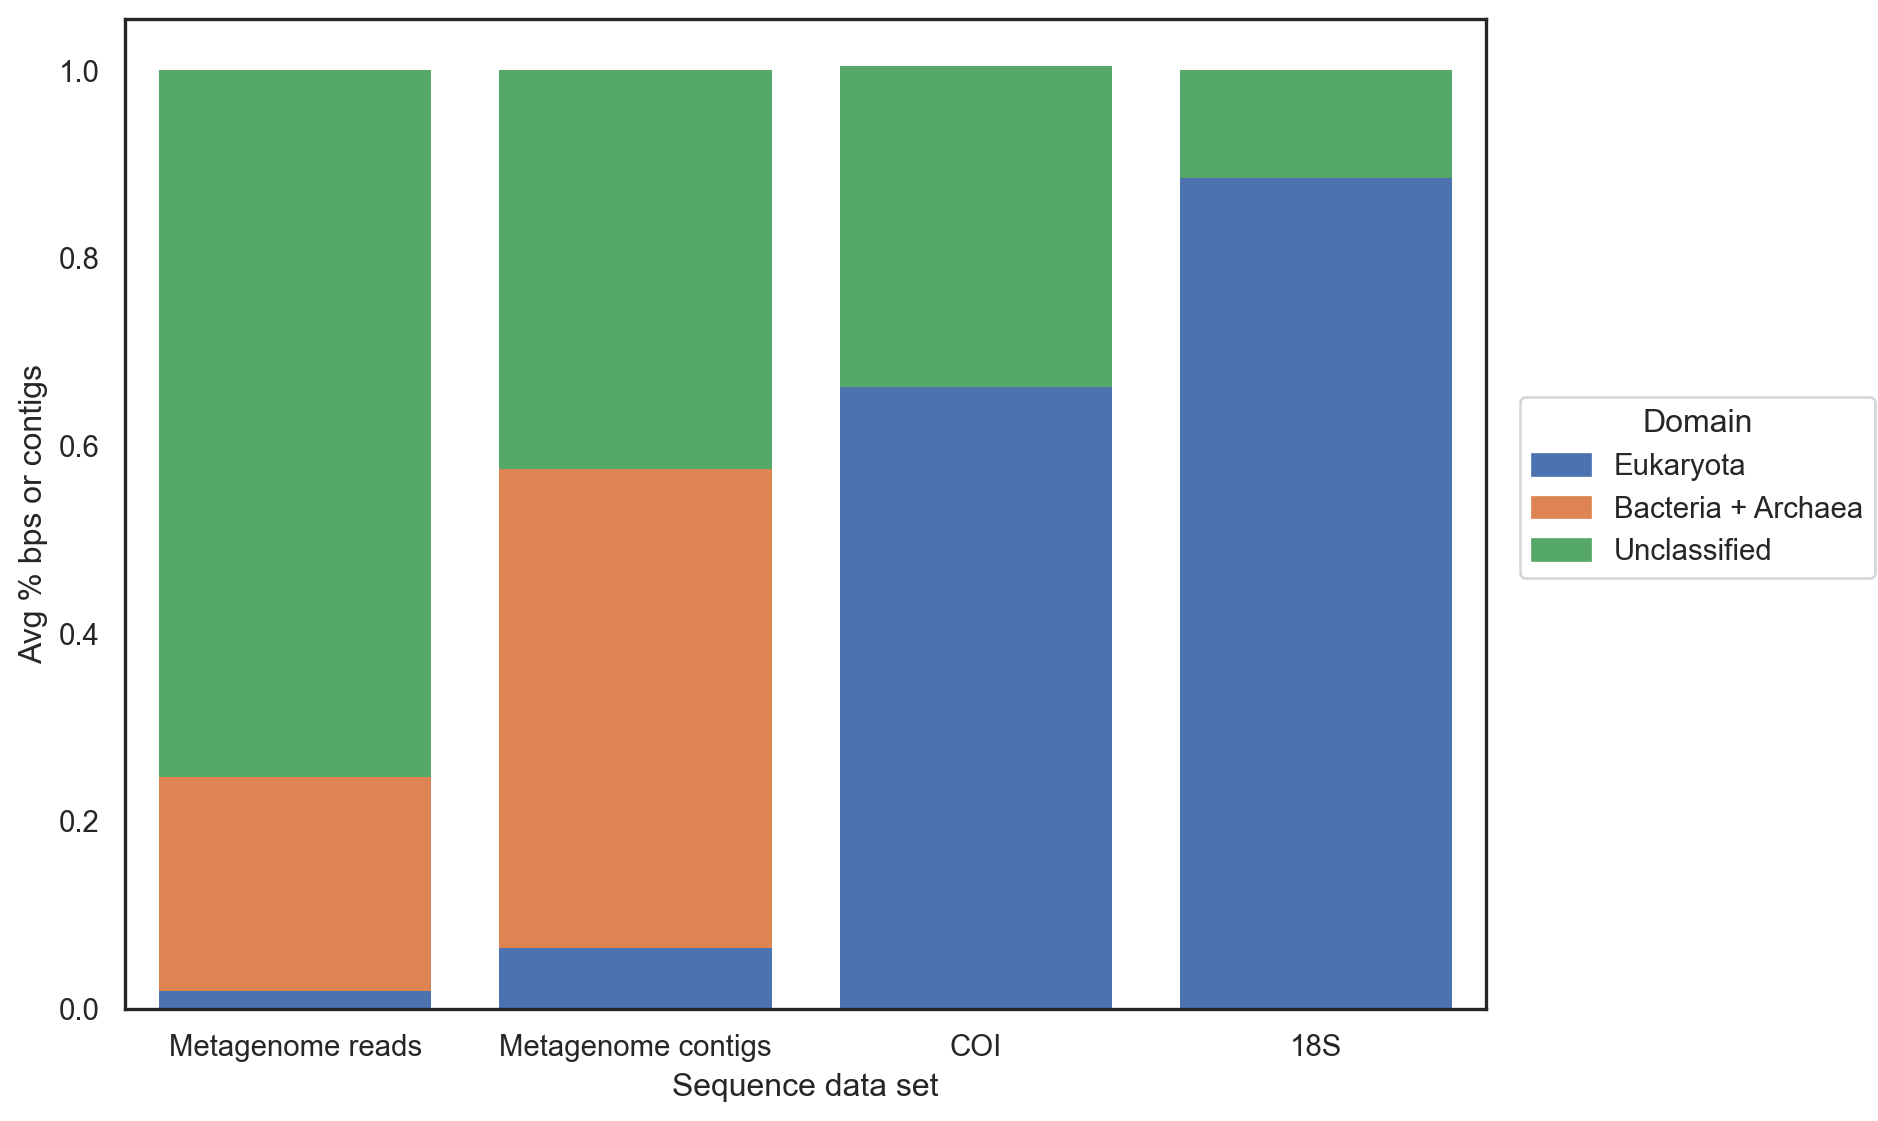

In [84]:
p = so.Plot(df, 
            x="Sequence type", 
            y="Avg % bps or contigs", 
            color="Domain").add(so.Bar(alpha=1.0), 
                                so.Stack()).layout(size=(8, 6))
p = p.theme(axes_style('white'))
p = p.label(x = 'Sequence data set')
p

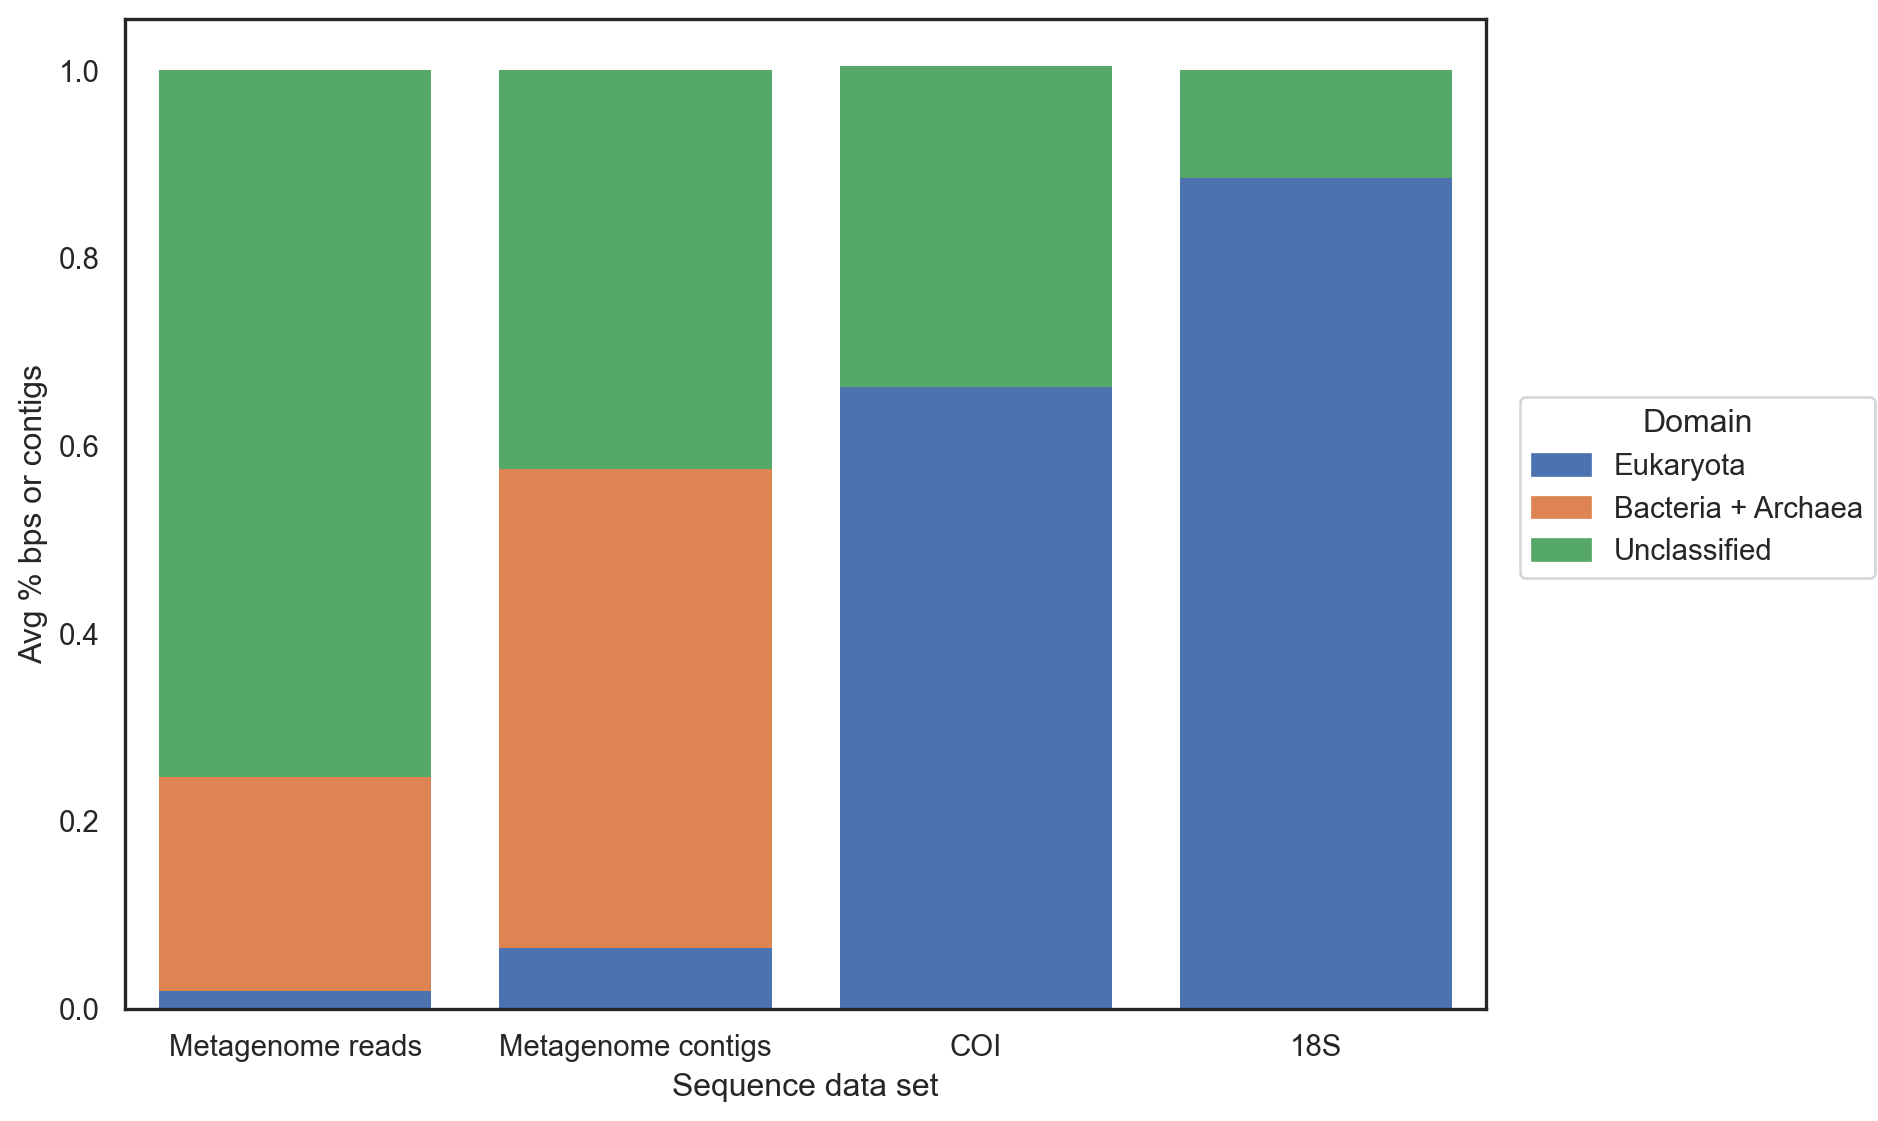

In [85]:
p.save('CCE-2018_2019_prok_vs_euk_reads.svg', format='svg', 
            dpi=1200, bbox_inches='tight')

## 05. Compare frequencies of taxa seen in paired samples: ORFs vs amplicons

In [86]:
os.chdir("/Users/nastassiapatin/GitHub/Euk-eDNA-comparison/")

In [87]:
def combine_ASV_metagenome_freqs(sample_key, mgn_df, asv_df, marker_gene, tax_level1, tax_level2): 
    asv_df = asv_df.rename(columns={'%s sample' % marker_gene: 'ASV sample'})
    asv_df_taxon = pd.DataFrame(asv_df[['%s' % tax_level1,
                                        '%s' % tax_level2,
                                        'ASV sample', 
                                        '%s reads' % marker_gene]].groupby(['%s' % tax_level1,
                                                                            '%s' % tax_level2,
                                                                           'ASV sample'],
                                                                           as_index=False).sum())
    df_tax_asvs_paired = asv_df_taxon.merge(sample_key, how='left', on='ASV sample')
    df_tax_mgns_paired = mgn_df.merge(sample_key, how='left', on='Metagenome sample')
    return(df_tax_asvs_paired, df_tax_mgns_paired)

#### Load file showing paired sample names and turn pairs into a dictionary

In [88]:
file = 'eCruises2018_2019_mgn_asv_paired_samples.csv'
pairs = pd.read_csv(file)
pairs.head(3)

,ASV sample,Metagenome sample
0,CN18FESPkoa_SC24,zr2760_52
1,CN18FESPkoa_SC26,zr2760_64
2,CN18FESPkoa_SC29,zr2760_79


##### Import existing dfs

In [89]:
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/18S comparison")
df_freq_18S = pd.read_csv("18S_frequencies_all_tax_ranks.csv")
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/COI comparison")
df_freq_COI = pd.read_csv("COI_frequencies_all_tax_ranks.csv")
os.chdir("/Users/nastassiapatin/OneDrive - SCCWRP/Euks_mgns_asvs/mmseqs")
mmseqs_tax = pd.read_csv("CCE_2018-2019_mmseqs_taxa.csv")

In [90]:
mmseqs_tax.head()

,Metagenome sample,Best_tax,percent_TPM,Phylum,Kingdom,Class,Order,Family,Genus,Species
0,D0174A,50 kb inversion clade,4.445952e-07,Streptophyta,Viridiplantae,Magnoliopsida,Fabales,Fabaceae,NaN,NaN
1,D0174A,Abrus precatorius,6.064442e-07,Streptophyta,Viridiplantae,Magnoliopsida,Fabales,Fabaceae,Abrus,Abrus precatorius
2,D0174A,Absidia glauca,1.046062e-06,Mucoromycota,Fungi,Mucoromycetes,Mucorales,Cunninghamellaceae,Absidia,Absidia glauca
3,D0174A,Absidia repens,1.355780e-06,Mucoromycota,Fungi,Mucoromycetes,Mucorales,Cunninghamellaceae,Absidia,Absidia repens
4,D0174A,Acalypheae,1.861661e-07,Streptophyta,Viridiplantae,Magnoliopsida,Malpighiales,Euphorbiaceae,NaN,NaN


##### Group metagenome taxonomy by Phylum and Class

In [91]:
mmseqs_phy = mmseqs_tax.groupby(['Phylum', 'Class', 'Metagenome sample']).sum().reset_index().drop(columns=['Best_tax',
                                                                                                            'Kingdom',
                                                                                                            'Order',
                                                                                                            'Family',
                                                                                                            'Genus','Species'])
mmseqs_phy.head()

,Phylum,Class,Metagenome sample,percent_TPM
0,Acantharea,Acantharea,D0052A,3.073382e-07
1,Acantharea,Acantharea,D0053A,1.477337e-07
2,Acantharea,Acantharea,D0128A,1.206552e-07
3,Acantharea,Acantharea,D0174A,1.174835e-07
4,Acantharea,Acantharea,zr2760_64,3.970424e-07


### Parse metagenomes and each marker gene separately

In [106]:
# 18S
asvs, mgns = combine_ASV_metagenome_freqs(pairs, 
                                          mmseqs_phy, 
                                          df_freq_18S, 
                                          '18S', 
                                          'Phylum',
                                         'Class')

In [93]:
# COI
asvs, mgns = combine_ASV_metagenome_freqs(pairs, 
                                          mmseqs_tax, 
                                          df_freq_COI, 
                                          'COI', 
                                          'Phylum', 
                                          'Class')

### Combine ASV and metagenome taxa frequences at the Phylum AND Class levels

In [107]:
df_tax_pairmatches = mgns.merge(asvs, how='outer', 
                                            on=['Phylum', 
                                                'Class',
                                                'ASV sample', 
                                                'Metagenome sample'])
df_tax_pairmatches.head(10)

,Phylum,Class,Metagenome sample,percent_TPM,ASV sample,18S reads
0,Acantharea,Acantharea,zr2760_52,NaN,CN18FESPkoa_SC24,0.037783
1,Acantharea,Acantharea,zr2760_64,3.970424e-07,CN18FESPkoa_SC26,0.036214
2,Acantharea,Acantharea,zr2760_79,1.423334e-06,CN18FESPkoa_SC29,0.050681
3,Acantharea,Acantharea,zr2760_59,NaN,CN18FESPkoa_SC30,0.044709
4,Acantharea,Acantharea,zr2760_48,NaN,CN18FESPkoa_SC31,0.002538
5,Acantharea,Acantharea,zr2760_50,NaN,CN18FESPkoa_SC32,0.001358
6,Acantharea,Acantharea,zr2760_38,NaN,CN18FESPkoa_SC34,0.002261
7,Acantharea,Acantharea,zr2760_62,NaN,CN18FESPkoa_SC35,0.005809
8,Acantharea,Acantharea,zr2760_53,NaN,CN18FESPkoa_SC37,0.014796
9,Acantharea,Acantharea,zr2760_49,NaN,CN18FESPkoa_SC40,0.021516


## In cases where a sample has no matching sample containing any of the same phylum/class combo, need to add in the corresponding sample name and replace content with '0'

In [108]:
# Create a dictionary 
value_map = pairs.set_index('ASV sample')['Metagenome sample'].to_dict()
#value_map

In [109]:
# Use map to replace NaN 'Metagenome sample' values in df_tax_pairmatches
df_tax_pairmatches['Metagenome sample'] = df_tax_pairmatches.apply(lambda row: 
                                                            value_map[row['ASV sample']] if pd.isna(row['Metagenome sample']) 
                                                            else row['Metagenome sample'], axis=1)

In [110]:
# Create the inverse dictionary
value_map = pairs.set_index('Metagenome sample')['ASV sample'].to_dict()
#value_map

In [111]:
# Use map to replace NaN 'ASV sample' values in df_tax_pairmatches
df_tax_pairmatches['ASV sample'] = df_tax_pairmatches.apply(lambda row: 
                                                            value_map[row['Metagenome sample']] if pd.isna(row['ASV sample']) 
                                                            else row['ASV sample'], axis=1)

In [112]:
df_tax_pairmatches

,Phylum,Class,Metagenome sample,percent_TPM,ASV sample,18S reads
0,Acantharea,Acantharea,zr2760_52,NaN,CN18FESPkoa_SC24,0.037783
1,Acantharea,Acantharea,zr2760_64,3.970424e-07,CN18FESPkoa_SC26,0.036214
2,Acantharea,Acantharea,zr2760_79,1.423334e-06,CN18FESPkoa_SC29,0.050681
3,Acantharea,Acantharea,zr2760_59,NaN,CN18FESPkoa_SC30,0.044709
4,Acantharea,Acantharea,zr2760_48,NaN,CN18FESPkoa_SC31,0.002538
...,...,...,...,...,...,...
54788,unknown,unknown,D0174A,NaN,Lasker18Sc135_19_D0174,0.059422
54789,unknown,unknown,D0275A,NaN,Lasker18Sc158_17_D0275,0.053545
54790,unknown,unknown,D0276A,NaN,Lasker18Sc158_19_D0276,0.042718
54791,unknown,unknown,D0270A,NaN,Lasker18Sc158_3_D0270,0.184166


In [113]:
# Replace NaN in 'percent_TPM' and 'COI reads' or '18S reads' columns with '0'
df_tax_pairmatches['percent_TPM'] = df_tax_pairmatches['percent_TPM'].fillna(0)
df_tax_pairmatches['18S reads'] = df_tax_pairmatches['18S reads'].fillna(0)

In [114]:
df_tax_pairmatches

,Phylum,Class,Metagenome sample,percent_TPM,ASV sample,18S reads
0,Acantharea,Acantharea,zr2760_52,0.000000e+00,CN18FESPkoa_SC24,0.037783
1,Acantharea,Acantharea,zr2760_64,3.970424e-07,CN18FESPkoa_SC26,0.036214
2,Acantharea,Acantharea,zr2760_79,1.423334e-06,CN18FESPkoa_SC29,0.050681
3,Acantharea,Acantharea,zr2760_59,0.000000e+00,CN18FESPkoa_SC30,0.044709
4,Acantharea,Acantharea,zr2760_48,0.000000e+00,CN18FESPkoa_SC31,0.002538
...,...,...,...,...,...,...
54788,unknown,unknown,D0174A,0.000000e+00,Lasker18Sc135_19_D0174,0.059422
54789,unknown,unknown,D0275A,0.000000e+00,Lasker18Sc158_17_D0275,0.053545
54790,unknown,unknown,D0276A,0.000000e+00,Lasker18Sc158_19_D0276,0.042718
54791,unknown,unknown,D0270A,0.000000e+00,Lasker18Sc158_3_D0270,0.184166


#### Need this step to avoid 'nan' values in the exported file!

In [115]:
df_tax_pairmatches['Class']= df_tax_pairmatches['Class'].astype(pd.StringDtype())
df_tax_pairmatches.dtypes

Phylum                       object
Class                string[python]
Metagenome sample            object
percent_TPM                 float64
ASV sample                   object
18S reads                   float64
dtype: object

In [116]:
os.chdir("/Users/nastassiapatin/GitHub/Euk-eDNA-comparison/18S comparison")
df_tax_pairmatches.to_csv("Phylum_Class_18S_samplepairs.csv", index=False)